# Multi-Perturbation Kinematic Reconstruction

Runs the full train-size sweep (`TRAIN_SIZES`) independently for each entry in
`PERTURBATION_SEEDS`. Each seed produces a fresh random perturbation drawn from
the same `RANDOM_PERT_BOUNDS`, so the final summary shows how much the
reconstruction accuracy depends on *which* perturbation was applied, not just
a single lucky/unlucky instance.

**Outer loop** (seeds) × **inner loop** (train sizes):
- Per seed: regenerate flux / centroids / motor-positions from scratch, re-filter,
  re-split, train Stage 1 + Stage 2 for every train size.
- Polar and loss-curve plots are shown **only for the first seed** to avoid clutter.
- **Summary**: learning curve with mean ± std band across seeds.

## Imports

In [1]:
import json
import pathlib
import sys
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from tqdm import tqdm as tqdm_nb

warnings.filterwarnings("ignore")

_nb   = pathlib.Path(globals().get("__vsc_ipynb_file__", pathlib.Path().resolve() / "x")).parent
_src  = _nb.parent
_base = _src.parent
_repo = _base.parent
sys.path.insert(0, str(_src))
sys.path.insert(0, str(_repo / "PAINT"))

from artist.raytracing.heliostat_ray_tracer import HeliostatRayTracer
from artist.scenario.scenario import Scenario
from artist.util import get_device, set_logger_config, indices
from artist.optim.loss import FocalSpotLoss

from utils.synth_data import (
    _forward_pass,
    apply_perturbations,
    reset_perturbations,
    sample_perturbations,
    SyntheticDatasetParser,
)
from artist_extensions.loss_functions_ext import AlignmentLoss
from paint.data.dataset_splits import DatasetSplitter
import paint.util.paint_mappings as paint_mappings

set_logger_config()
import logging
logging.getLogger().setLevel(logging.WARNING)

print("Imports OK")

Imports OK


## Configuration

The only cell to change between experiments.

In [2]:
# ============================================================
#  CONFIG
# ============================================================

HELIOSTAT_ID = "AO34"
DATASET_SPLIT_TYPE = "azimuth_dataset"

# One full training sweep is run per seed.
PERTURBATION_SEEDS = [42, 123, 456, 789, 1337]

# Perturbation bounds — same for every seed.
RANDOM_PERT_BOUNDS = {
    "rotation_rad":       0.005,
    "actuator_angle_rad": 0.005,
    "actuator_stroke_m":  0.005,
    "actuator_offset_m":  0.005,
    "translation_m":      0.05,
    "base_position_m":    0.05,
}

TRAIN_SIZES = [1, 3, 5, 10, 15, 20, 30, 50, 70, 100]
VAL_SIZE    = 50

# If True: train=sunrise, val=noon, test=sunset (sunset never seen during training).
# If False (default): train=sunrise, val=sunset, test=noon.
SWAP_VAL_TEST = True

SURFACE_POINTS_PER_FACET = 25
TRAIN_RAYS    = 10
DISPLAY_RAYS  = 50
GENERATE_RAYS = 100

STAGE1_EPOCHS   = 20
STAGE2_EPOCHS   = 100
MINI_BATCH_SIZE = 25
BASE_LR         = 1e-4

MIN_ACTIVE_PIXEL_PERCENT = 2.0

# ---- Paths -------------------------------------------------------------------
SCENARIO_PATH     = _base / "scenarios" / "one_heliostat_scenarios" / HELIOSTAT_ID / "scenario.h5"
SYNTH_DATASET_DIR = _base / "datasets" / "synthetic" / DATASET_SPLIT_TYPE / "dataset"

print(f"Heliostat : {HELIOSTAT_ID}")
print(f"Seeds     : {PERTURBATION_SEEDS}")
print(f"Train sizes: {TRAIN_SIZES}")

Heliostat : AO34
Seeds     : [42, 123, 456, 789, 1337]
Train sizes: [1, 3, 5, 10, 15, 20, 30, 50, 70, 100]


## Load Scenario

In [3]:
device = get_device()
print(f"Device: {device}")

with h5py.File(SCENARIO_PATH, "r") as f:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=f,
        device=device,
        number_of_surface_points_per_facet=torch.tensor(
            [SURFACE_POINTS_PER_FACET, SURFACE_POINTS_PER_FACET]
        ),
    )

heliostat_group = scenario.heliostat_field.heliostat_groups[0]
kinematic       = heliostat_group.kinematics

hel_pos   = heliostat_group.positions[0, :3].float()
_planar   = scenario.solar_tower.target_areas[indices.planar_target_areas]
tower_ref = _planar.centers[:, :3].float().mean(dim=0).to(device)
hel_dist_m = torch.norm(hel_pos - tower_ref).item()

print(f"Heliostat: {HELIOSTAT_ID}  |  dist-to-tower = {hel_dist_m:.1f} m")

[2026-06-06 15:11:52,188][artist.util.env][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-06-06 15:11:52,189][artist.util.env][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
Device: cpu
[2026-06-06 15:11:52,190][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2026-06-06 15:11:52,191][artist.field.tower_target_areas_planar][INFO] - Loading the planar tower target areas from an HDF5 file.
[2026-06-06 15:11:52,193][artist.field.tower_target_areas_cylindrical][INFO] - Loading the cylindrical tower target areas from an HDF5 file.
[2026-06-06 15:11:52,195][artist.scene.light_source_array][INFO] - Loading a light source array from an HDF5 file.
[2026-06-06 15:11:52,195][artist.scene.sun][INFO] - Loading sun_1 from an HDF5 file.
[2026-06-06 15:11:52,197][artist.scene.sun][INFO] - Initializing a sun modeled with a multivariate normal distribut

## Load Base Geometry

Loads the on-disk pool once to get `rays_raw` and `target_mask_raw` — the sun
positions that stay **fixed across all perturbation seeds**. Flux, centroids, and
motor positions are regenerated per seed in the sweep below.

In [4]:
def _parse_split(split_name: str, n: int):
    parser  = SyntheticDatasetParser(SYNTH_DATASET_DIR / split_name)
    mapping = [(HELIOSTAT_ID, list(range(n)), list(range(n)))]
    flux, cents, rays, mp, _am, tm = parser.parse_data_for_reconstruction(
        heliostat_data_mapping=mapping,
        heliostat_group=heliostat_group,
        scenario=scenario,
        device=device,
    )
    return flux, cents, rays, mp, tm

N_DISK = {}
for s in ("train", "val", "test"):
    d = SYNTH_DATASET_DIR / s / HELIOSTAT_ID
    if d.exists():
        N_DISK[s] = sum(1 for p in d.iterdir() if p.is_dir())

parts = [_parse_split(s, n) for s, n in N_DISK.items()]
rays_raw        = torch.cat([p[2] for p in parts], dim=0)   # [N_RAW, 4]
target_mask_raw = torch.cat([p[4] for p in parts], dim=0)   # [N_RAW]
N_RAW = rays_raw.shape[0]

print(f"Disk splits : {N_DISK}")
print(f"Base geometry: {N_RAW} samples  (rays shape: {tuple(rays_raw.shape)})")

Disk splits : {'train': 99, 'val': 49, 'test': 61}
Base geometry: 209 samples  (rays shape: (209, 4))


## Seed Scanner

Scan seeds 1–100 and collect the first 10 that survive the active-pixel filter
with enough samples to cover the full sweep (`max(TRAIN_SIZES) + VAL_SIZE + 10`).

In [5]:
# ── Seed scanner: find 10 seeds in [1, 100] that survive the active-pixel filter ──
SCAN_RAYS      = 10   # fewer rays → faster; only flux presence matters, not accuracy
SCAN_PASS_N    = max(TRAIN_SIZES) + VAL_SIZE + 10   # min pool to run the full sweep
N_SEEDS_WANTED = 10

passing_seeds = []
scan_log      = []

scenario.set_number_of_rays(SCAN_RAYS)
_am_all = torch.tensor([N_RAW], device=device, dtype=torch.long)

for _s in tqdm_nb(range(1, 101), desc="Scanning seeds"):
    _pert = sample_perturbations(1, RANDOM_PERT_BOUNDS, _s)
    _orig = apply_perturbations(heliostat_group.kinematics, _pert, device)

    with torch.no_grad():
        heliostat_group.activate_heliostats(active_heliostats_mask=_am_all, device=device)
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.solar_tower.get_centers_of_target_areas(target_mask_raw, device),
            incident_ray_directions=rays_raw,
            active_heliostats_mask=_am_all,
            device=device,
        )
        _, _flux = _forward_pass(
            scenario, heliostat_group,
            rays_raw, _am_all, target_mask_raw,
            torch.zeros(1, 3, device=device), device,
        )

    reset_perturbations(heliostat_group.kinematics, _orig)

    _active_pct = torch.tensor(
        [float((_flux[i] > 0).sum()) / float(_flux[i].numel()) * 100.0
         for i in range(N_RAW)],
        dtype=torch.float32,
    )
    _keep   = (_active_pct >= MIN_ACTIVE_PIXEL_PERCENT)
    n_total = int(_keep.sum().item())
    passed  = n_total >= SCAN_PASS_N

    scan_log.append({"seed": _s, "n_total": n_total, "passed": passed})
    if passed:
        passing_seeds.append(_s)
        if len(passing_seeds) >= N_SEEDS_WANTED:
            break

scenario.set_number_of_rays(TRAIN_RAYS)  # restore for training

print(f"Pass threshold : >= {SCAN_PASS_N} samples  "
      f"(max_train={max(TRAIN_SIZES)} + val={VAL_SIZE} + 10)")
print(f"Seeds scanned  : {len(scan_log)}")
print(f"Passing seeds  : {passing_seeds}\n")
print(f"  {'seed':>4}  {'n_kept':>6}  {'pass':>4}")
print(f"  {'----':>4}  {'------':>6}  {'----':>4}")
for r in scan_log:
    print(f"  {r['seed']:>4}  {r['n_total']:>6}  {'✓' if r['passed'] else '✗'}")

Scanning seeds:  22%|██▏       | 22/100 [00:18<01:04,  1.21it/s]

Pass threshold : >= 160 samples  (max_train=100 + val=50 + 10)
Seeds scanned  : 23
Passing seeds  : [1, 3, 4, 5, 10, 11, 12, 13, 15, 23]

  seed  n_kept  pass
  ----  ------  ----
     1     209  ✓
     2       0  ✗
     3     168  ✓
     4     209  ✓
     5     209  ✓
     6      75  ✗
     7      17  ✗
     8      41  ✗
     9      11  ✗
    10     209  ✓
    11     209  ✓
    12     209  ✓
    13     209  ✓
    14      87  ✗
    15     197  ✓
    16     111  ✗
    17      23  ✗
    18      87  ✗
    19       0  ✗
    20      41  ✗
    21     140  ✗
    22      11  ✗
    23     209  ✓


In [6]:
# Override PERTURBATION_SEEDS with the first 5 seeds found above.
# The sweep cell reads this variable, so running this cell before it
# is enough — no need to touch the config cell.
PERTURBATION_SEEDS = passing_seeds[:5]
print(f"PERTURBATION_SEEDS updated → {PERTURBATION_SEEDS}")

PERTURBATION_SEEDS updated → [1, 3, 4, 5, 10]


In [7]:
# ── Perturbation breakdown for the 5 selected seeds ──────────────────────────
_PARAM_META = [
    ("rotation",        "rad", 4),
    ("actuator_angle",  "rad", 2),
    ("actuator_stroke", "m",   2),
    ("actuator_offset", "m",   2),
    ("translation",     "m",   9),
    ("base_position",   "m",   3),
]

_perts = {s: sample_perturbations(1, RANDOM_PERT_BOUNDS, s) for s in PERTURBATION_SEEDS}

# ---- Raw values per seed ------------------------------------------------
for seed in PERTURBATION_SEEDS:
    p = _perts[seed]
    print(f"Seed {seed}")
    for key, unit, _ in _PARAM_META:
        vals     = p[key][0].numpy()
        vals_str = "  ".join(f"{v:+.4f}" for v in vals)
        print(f"  {key + ' (' + unit + ')':>26}:  {vals_str}")
    print()

# ---- L2-norm summary table (one value per param group per seed) ----------
header = f"  {'param':>26}  " + "  ".join(f"s={s:>4}" for s in PERTURBATION_SEEDS)
print(header)
print("  " + "-" * (len(header) - 2))
for key, unit, _ in _PARAM_META:
    norms = [float(_perts[s][key][0].norm()) for s in PERTURBATION_SEEDS]
    row   = f"  {key + ' (' + unit + ')':>26}  " + "  ".join(f"{n:>6.4f}" for n in norms)
    print(row)

Seed 1
              rotation (rad):  +0.0026  -0.0022  -0.0010  +0.0023
        actuator_angle (rad):  -0.0047  +0.0030
         actuator_stroke (m):  -0.0010  +0.0025
         actuator_offset (m):  +0.0007  -0.0006
             translation (m):  +0.0139  +0.0025  +0.0183  -0.0195  -0.0036  -0.0045  +0.0072  -0.0002  +0.0437
           base_position (m):  +0.0156  -0.0186  -0.0302

Seed 3
              rotation (rad):  -0.0050  -0.0039  -0.0021  -0.0047
        actuator_angle (rad):  -0.0003  -0.0044
         actuator_stroke (m):  +0.0027  +0.0024
         actuator_offset (m):  +0.0009  +0.0039
             translation (m):  -0.0049  +0.0299  -0.0350  -0.0099  -0.0446  -0.0041  -0.0324  +0.0449  +0.0347
           base_position (m):  +0.0375  +0.0148  -0.0285

Seed 4
              rotation (rad):  +0.0006  +0.0006  -0.0041  -0.0029
        actuator_angle (rad):  -0.0049  -0.0046
         actuator_stroke (m):  +0.0049  +0.0041
         actuator_offset (m):  +0.0012  +0.0047
           

## Helpers & Training Infrastructure

In [8]:
from nb_utils import (
    snapshot_kinematics, restore_kinematics,
    setup_optimizer, apply_bounds, clip_and_step, reset_for_new_run,
    compute_mrad, current_base_pos, eval_mrad,
    val_alignment_loss, val_focal_loss,
)

print("Helpers loaded from nb_utils.")

Helpers loaded from nb_utils.


## Initial Kinematic Snapshot

Taken once from the clean (unperturbed) scenario. Every training run resets to this state.

In [9]:
_hook_handles = []
_initial_snap = snapshot_kinematics(heliostat_group.kinematics)

k = heliostat_group.kinematics
print("Parameter norms (clean scenario):")
print(f"  translation:     {k.translation_deviation_parameters.norm().item():.6f}")
print(f"  rotation:        {k.rotation_deviation_parameters.norm().item():.6f}")
print(f"  actuator_angle:  {k.actuators.optimizable_parameters[:, indices.actuator_initial_angle, :].norm().item():.6f}")
print(f"  actuator_offset: {k.actuators.non_optimizable_parameters[:, indices.actuator_offset, :].norm().item():.6f}")

Parameter norms (clean scenario):
  translation:     0.175000
  rotation:        0.000000
  actuator_angle:  1.806936
  actuator_offset: 0.478076


## Multi-Perturbation Sweep

For each seed in `PERTURBATION_SEEDS`:
1. Sample a random perturbation and apply it temporarily to the kinematics.
2. Regenerate flux / centroids / motor-positions via ray tracing for all pool samples.
3. Restore the clean kinematics immediately — perturbation is only used for data generation.
4. Re-apply the active-pixel filter (per seed, since flux changes).
5. Run the full training sweep over `TRAIN_SIZES`.

Polar plots and loss curves are shown **for the first seed only**.
All numerical results are printed for every seed.


############################################################
  SEED 1  (1/5)
############################################################
  Perturbations applied:
                rotation (rad):  +0.0026  -0.0022  -0.0010  +0.0023
          actuator_angle (rad):  -0.0047  +0.0030
           actuator_stroke (m):  -0.0010  +0.0025
           actuator_offset (m):  +0.0007  -0.0006
               translation (m):  +0.0139  +0.0025  +0.0183  -0.0195  -0.0036  -0.0045  +0.0072  -0.0002  +0.0437
             base_position (m):  +0.0156  -0.0186  -0.0302
  Pool after filter: 209/209  (rejected 0)


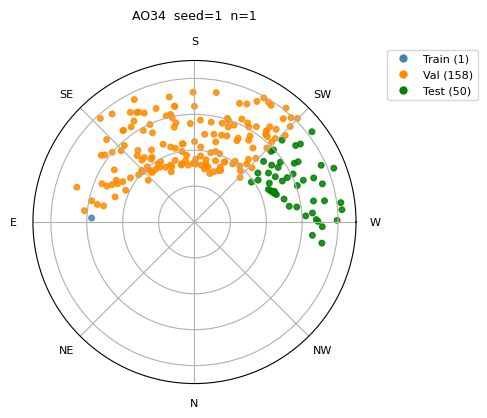

  n=   1:  mean=18.172 mrad   med=17.721 mrad


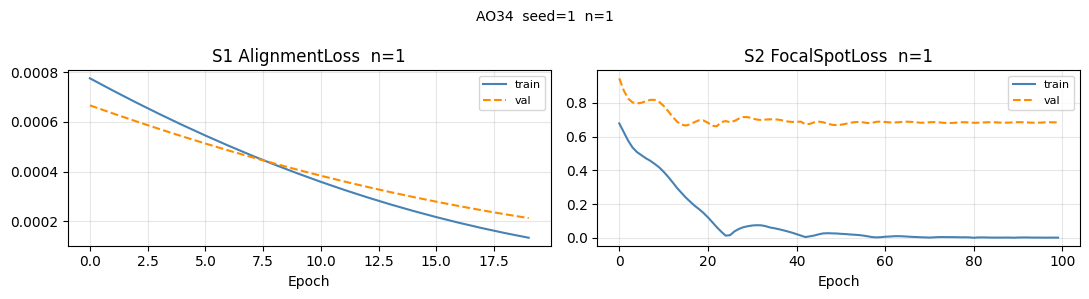

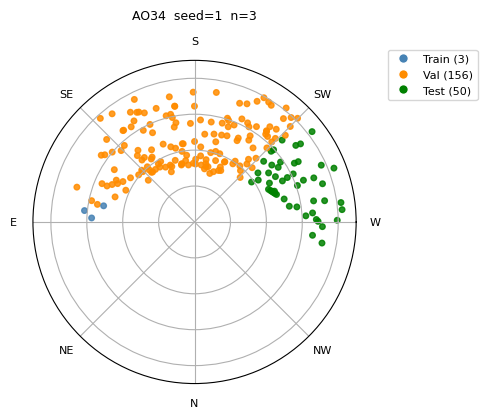

  n=   3:  mean=1.030 mrad   med=0.975 mrad


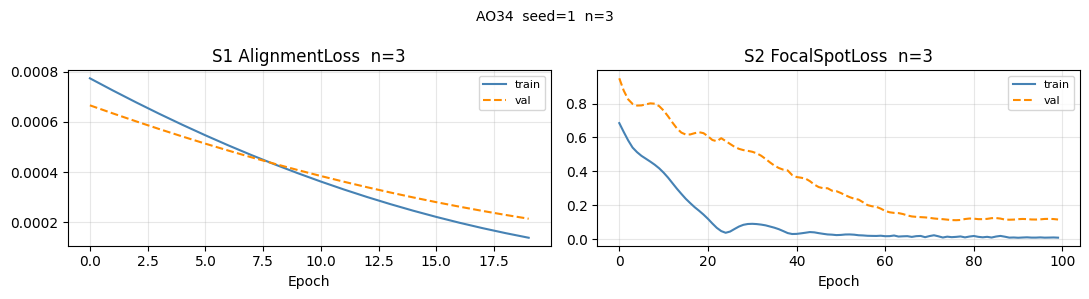

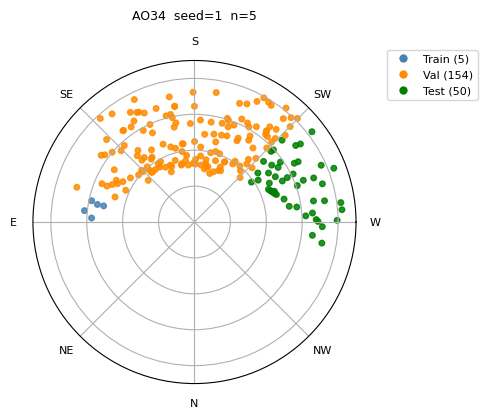

  n=   5:  mean=1.004 mrad   med=0.947 mrad


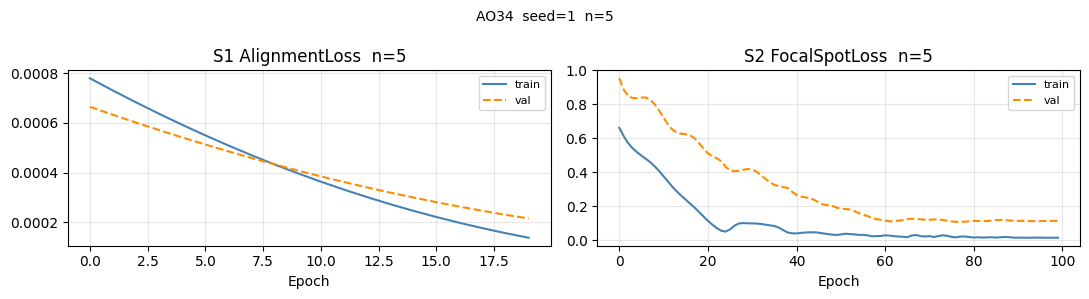

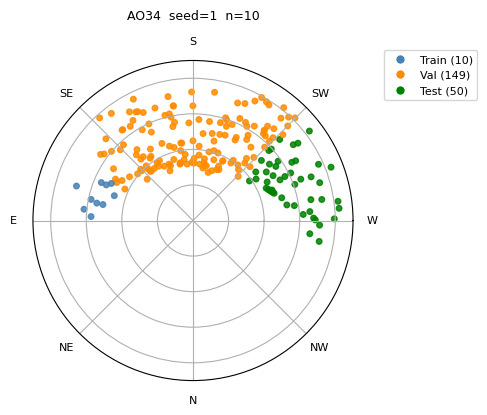

  n=  10:  mean=0.692 mrad   med=0.643 mrad


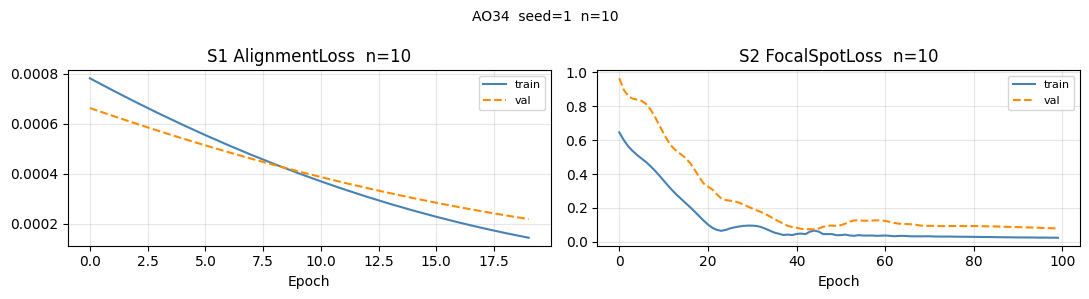

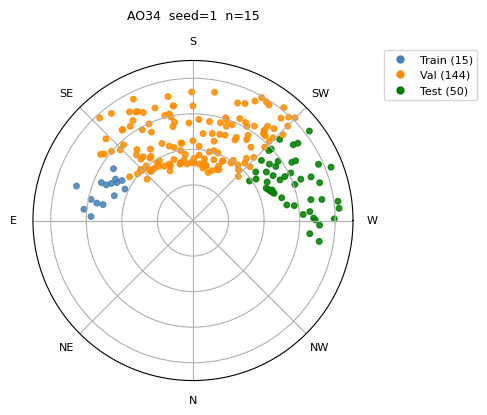

  n=  15:  mean=0.733 mrad   med=0.656 mrad


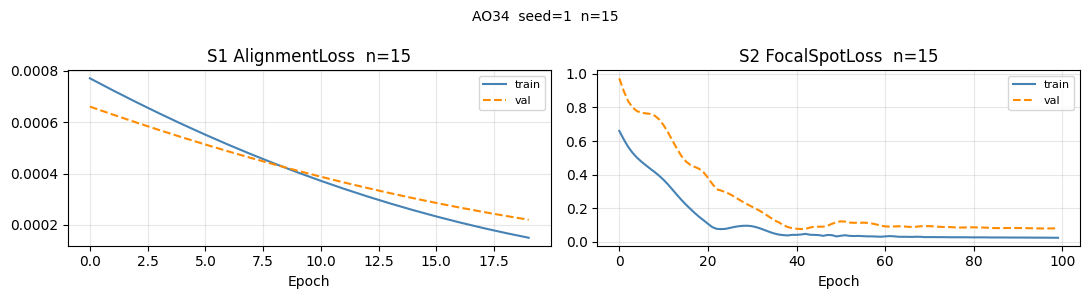

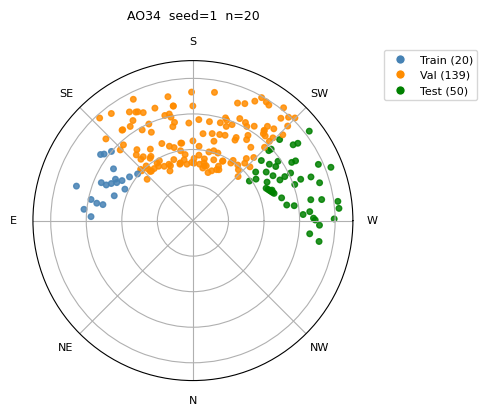

  n=  20:  mean=0.610 mrad   med=0.563 mrad


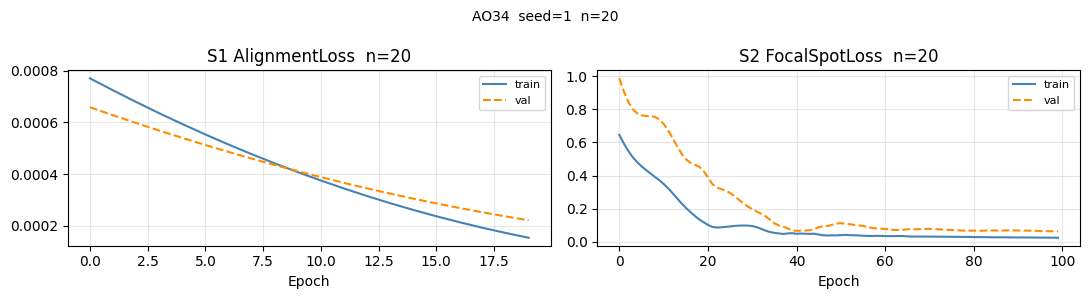

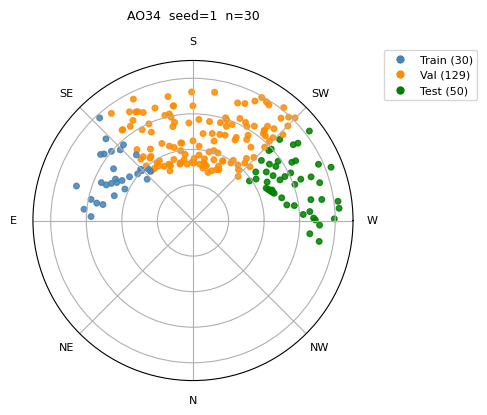

  n=  30:  mean=0.420 mrad   med=0.377 mrad


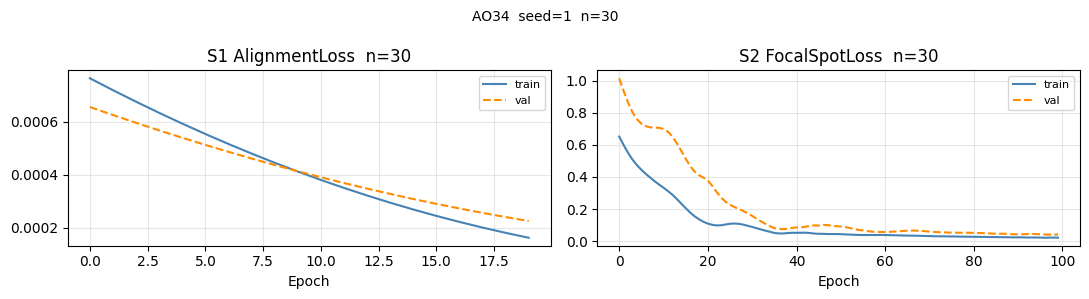

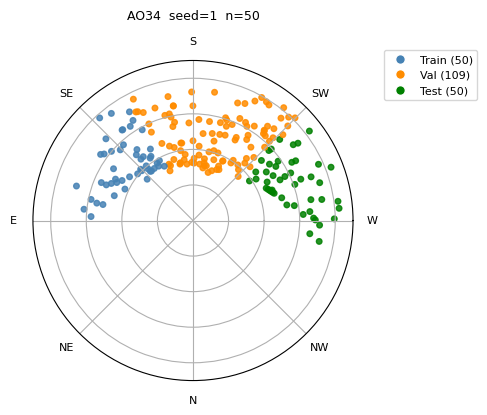

  n=  50:  mean=0.237 mrad   med=0.203 mrad


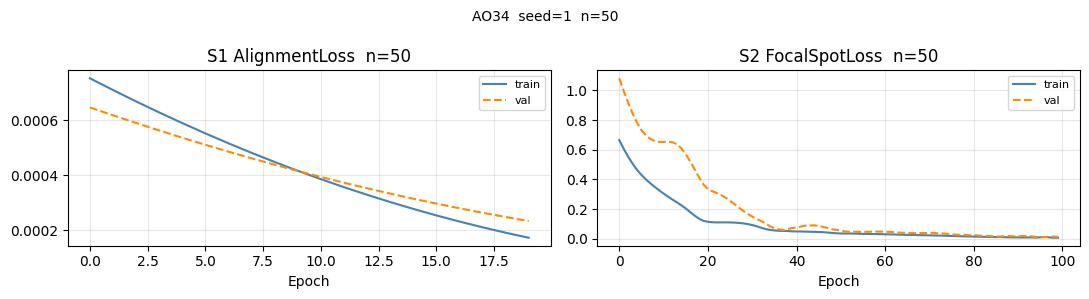

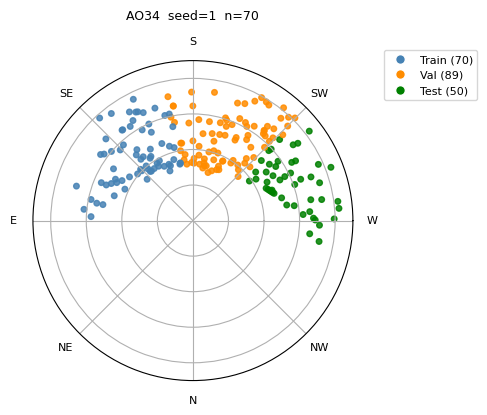

  n=  70:  mean=0.152 mrad   med=0.136 mrad


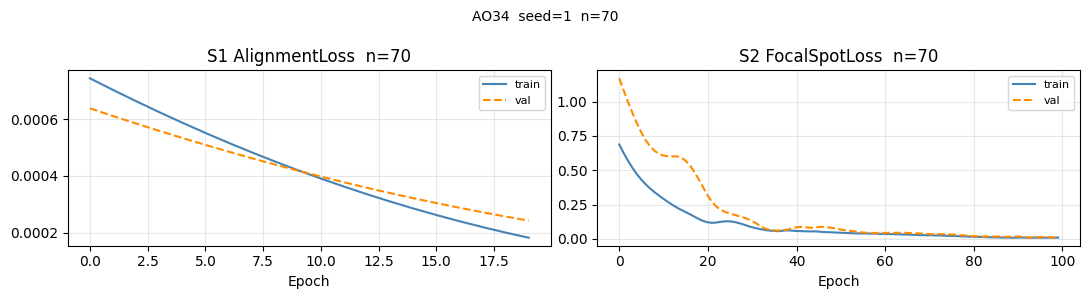

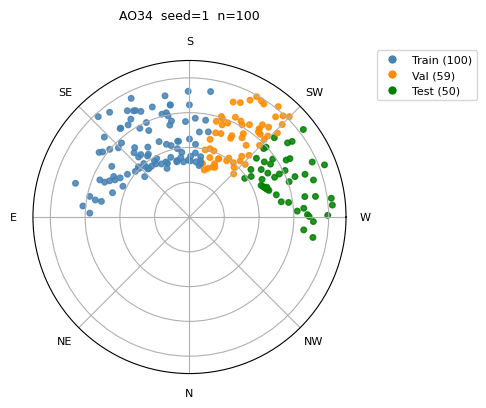

  n= 100:  mean=0.166 mrad   med=0.150 mrad


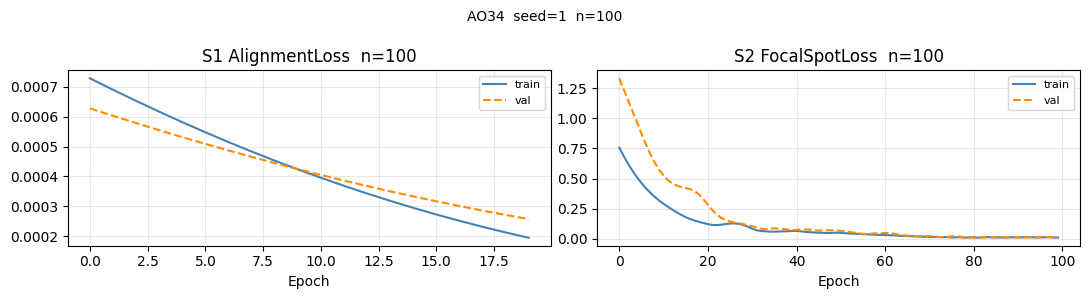

  Seed 1 complete — 10 train sizes.

############################################################
  SEED 3  (2/5)
############################################################
  Perturbations applied:
                rotation (rad):  -0.0050  -0.0039  -0.0021  -0.0047
          actuator_angle (rad):  -0.0003  -0.0044
           actuator_stroke (m):  +0.0027  +0.0024
           actuator_offset (m):  +0.0009  +0.0039
               translation (m):  -0.0049  +0.0299  -0.0350  -0.0099  -0.0446  -0.0041  -0.0324  +0.0449  +0.0347
             base_position (m):  +0.0375  +0.0148  -0.0285
  Pool after filter: 113/209  (rejected 96)


  n=   1:  mean=34.849 mrad   med=31.113 mrad


  n=   3:  mean=35.783 mrad   med=32.335 mrad


  n=   5:  mean=36.019 mrad   med=32.465 mrad


  n=  10:  mean=35.751 mrad   med=35.287 mrad


...

  n=  20:  mean=0.753 mrad   med=0.808 mrad


  n=  30:  mean=0.398 mrad   med=0.386 mrad


  n=  50:  mean=0.328 mrad   med=0.315 mrad


  n=  70:  mean=0.266 mrad   med=0.250 mrad


  n= 100:  mean=0.184 mrad   med=0.169 mrad
  Seed 10 complete — 10 train sizes.

All seeds complete.


In [10]:
multi_results = {}  # {seed: {train_size: {mean, med, per, s1_train, ...}}}

for _seed_idx, seed in enumerate(PERTURBATION_SEEDS):
    show_plots = (_seed_idx == 0)

    print(f"\n{'#'*60}")
    print(f"  SEED {seed}  ({_seed_idx + 1}/{len(PERTURBATION_SEEDS)})")
    print(f"{'#'*60}")

    # ---- 1. Generate perturbed pool data ---------------------------------
    # Apply perturbation, ray-trace the full pool, then immediately restore.
    _pert  = sample_perturbations(1, RANDOM_PERT_BOUNDS, seed)

    print("  Perturbations applied:")
    for _pk, _pu in [
        ("rotation",        "rad"),
        ("actuator_angle",  "rad"),
        ("actuator_stroke", "m"),
        ("actuator_offset", "m"),
        ("translation",     "m"),
        ("base_position",   "m"),
    ]:
        _pv = _pert[_pk][0].numpy()
        print(f"    {(_pk + ' (' + _pu + ')'):>26}:  " + "  ".join(f"{v:+.4f}" for v in _pv))

    _orig  = apply_perturbations(heliostat_group.kinematics, _pert, device)
    _am_all = torch.tensor([N_RAW], device=device, dtype=torch.long)

    with torch.no_grad():
        heliostat_group.activate_heliostats(active_heliostats_mask=_am_all, device=device)
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.solar_tower.get_centers_of_target_areas(target_mask_raw, device),
            incident_ray_directions=rays_raw,
            active_heliostats_mask=_am_all,
            device=device,
        )
        _motor_pos = heliostat_group.kinematics.active_motor_positions.detach().clone()

        scenario.set_number_of_rays(GENERATE_RAYS)
        _centroids, _flux = _forward_pass(
            scenario, heliostat_group,
            rays_raw, _am_all, target_mask_raw,
            torch.zeros(1, 3, device=device), device,
        )
        scenario.set_number_of_rays(TRAIN_RAYS)

    reset_perturbations(heliostat_group.kinematics, _orig)  # kinematics clean again

    # ---- 2. Active-pixel filter (per seed) --------------------------------
    _active_pct = torch.tensor(
        [float((_flux[i] > 0).sum()) / float(_flux[i].numel()) * 100.0
         for i in range(N_RAW)],
        dtype=torch.float32,
    )
    _keep    = (_active_pct >= MIN_ACTIVE_PIXEL_PERCENT)
    _keep_d  = _keep.to(_flux.device)
    _keep_c  = _keep.cpu()

    _flux_s  = _flux[_keep_d]
    _cents_s = _centroids[_keep_d]
    _rays_s  = rays_raw[_keep_c]
    _mp_s    = _motor_pos[_keep_c]
    _tm_s    = target_mask_raw[_keep_c]
    N_TOTAL  = int(_keep.sum().item())

    print(f"  Pool after filter: {N_TOTAL}/{N_RAW}  (rejected {N_RAW - N_TOTAL})")

    # ---- 3. Splitting DataFrame -------------------------------------------
    _sun = -_rays_s.cpu().numpy()
    _az  = np.degrees(np.arctan2(_sun[:, 0], _sun[:, 1])) % 360.0
    _el  = np.degrees(np.arcsin(np.clip(_sun[:, 2], -1.0, 1.0)))

    heliostat_df = pd.DataFrame({
        paint_mappings.HELIOSTAT_ID: HELIOSTAT_ID,
        paint_mappings.AZIMUTH:      _az,
        paint_mappings.ELEVATION:    _el,
        paint_mappings.DATETIME:     pd.Timestamp("2020-06-15 12:00:00"),
        paint_mappings.SPLIT_KEY:    "",
    }, index=range(N_TOTAL))

    # ---- 4. Training sweep ------------------------------------------------
    seed_results = {}

    for train_size in TRAIN_SIZES:
        if N_TOTAL < train_size + VAL_SIZE + 10:
            continue

        # Azimuth split
        _split_df = DatasetSplitter._get_azimuth_splits(
            heliostat_df.copy(), training_size=train_size, validation_size=VAL_SIZE
        )
        train_idx = _split_df[_split_df[paint_mappings.SPLIT_KEY] == paint_mappings.TRAIN_INDEX].index.tolist()
        val_idx   = _split_df[_split_df[paint_mappings.SPLIT_KEY] == paint_mappings.VALIDATION_INDEX].index.tolist()
        test_idx  = _split_df[_split_df[paint_mappings.SPLIT_KEY] == paint_mappings.TEST_INDEX].index.tolist()

        if SWAP_VAL_TEST:
            val_idx, test_idx = test_idx, val_idx

        def _slice(idx):
            t = torch.tensor(idx, device=device)
            return (
                _flux_s[t], _cents_s[t], _rays_s[t], _mp_s[t], _tm_s[t],
                torch.tensor([len(idx)], device=device, dtype=torch.long),
            )

        s_flux, s_cents, s_rays, s_mp, s_tm, s_am = _slice(train_idx)
        v_flux, v_cents, v_rays, v_mp, v_tm, v_am = _slice(val_idx)
        t_flux, t_cents, t_rays, t_mp, t_tm, t_am = _slice(test_idx)

        # Polar plot (first seed only)
        if show_plots:
            _colors = np.full(N_TOTAL, "lightgray", dtype=object)
            for i in train_idx: _colors[i] = "steelblue"
            for i in val_idx:   _colors[i] = "darkorange"
            for i in test_idx:  _colors[i] = "green"
            fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
            ax.scatter(3*np.pi/2 - np.radians(_az), 90 - _el, s=16, c=list(_colors), alpha=0.85)
            ax.legend(handles=[
                Line2D([0],[0], marker="o", color="w", markerfacecolor="steelblue",  markersize=7, label=f"Train ({len(train_idx)})"),
                Line2D([0],[0], marker="o", color="w", markerfacecolor="darkorange", markersize=7, label=f"Val ({len(val_idx)})"),
                Line2D([0],[0], marker="o", color="w", markerfacecolor="green",      markersize=7, label=f"Test ({len(test_idx)})"),
            ], loc="upper left", bbox_to_anchor=(1.08, 1.05), fontsize=8)
            ax.set_rlim(0, 90); ax.set_rticks([20, 40, 60, 80])
            ax.set_yticklabels([]); ax.set_rlabel_position(135)
            ax.set_xticklabels(["W","SW","S","SE","E","NE","N","NW"], fontsize=8)
            ax.set_title(f"{HELIOSTAT_ID}  seed={seed}  n={train_size}", fontsize=9, pad=12)
            plt.tight_layout(); plt.show()

        # Reset kinematics
        reset_for_new_run(heliostat_group.kinematics, _initial_snap, _hook_handles)
        kinematic = heliostat_group.kinematics
        optimizer_s1, _hook_handles = setup_optimizer(kinematic, BASE_LR, device)
        scheduler_s1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_s1, mode="min", factor=0.5, patience=10, threshold=1e-4, cooldown=5, min_lr=1e-8
        )
        alignment_loss_fn = AlignmentLoss()
        s1_train_losses, s1_val_losses = [], []

        # Stage 1 — AlignmentLoss
        for epoch in tqdm_nb(range(1, STAGE1_EPOCHS + 1), desc=f"S1 seed={seed} n={train_size}", leave=False):
            optimizer_s1.zero_grad()
            kinematic = heliostat_group.kinematics
            heliostat_group.activate_heliostats(active_heliostats_mask=s_am, device=device)
            _bpd = kinematic._base_position_deviation
            _rep = _bpd.repeat_interleave(s_am, dim=0)
            kinematic.active_heliostat_positions = (
                kinematic.active_heliostat_positions
                + torch.cat([_rep, torch.zeros(_rep.shape[0], 1, device=device)], dim=1)
            )
            heliostat_group.align_surfaces_with_incident_ray_directions(
                aim_points=scenario.solar_tower.get_centers_of_target_areas(s_tm, device),
                incident_ray_directions=s_rays,
                active_heliostats_mask=s_am,
                device=device,
            )
            loss = alignment_loss_fn(
                predicted_motor_positions=kinematic.active_motor_positions,
                measured_motor_positions=s_mp,
                actuators=kinematic.actuators,
                device=device,
            ).mean()
            loss.backward()
            clip_and_step(optimizer_s1, kinematic)
            s1_train_losses.append(loss.item())
            s1_val_losses.append(val_alignment_loss(v_rays, v_am, v_tm, v_mp, kinematic, alignment_loss_fn, scenario=scenario, heliostat_group=heliostat_group, device=device))
            scheduler_s1.step(s1_val_losses[-1])

        # Stage 1 → Stage 2 transition
        kinematic._base_position_deviation = kinematic._base_position_deviation.detach().requires_grad_(True)
        optimizer_s2 = torch.optim.Adam(
            [
                {"params": kinematic.translation_deviation_parameters,  "lr": BASE_LR * 5.0},
                {"params": kinematic.rotation_deviation_parameters,     "lr": BASE_LR},
                {"params": kinematic.actuators.optimizable_parameters,  "lr": BASE_LR},
                {"params": kinematic._base_position_deviation,          "lr": BASE_LR * 5.0},
            ],
            lr=BASE_LR,
        )
        scheduler_s2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_s2, mode="min", factor=0.5, patience=10, threshold=1e-4, cooldown=5, min_lr=1e-8
        )
        focal_loss_fn = FocalSpotLoss(scenario=scenario)
        s2_train_losses, s2_val_losses = [], []
        n_mb = max(1, (len(train_idx) + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE)

        # Stage 2 — FocalSpotLoss
        for epoch in tqdm_nb(range(1, STAGE2_EPOCHS + 1), desc=f"S2 seed={seed} n={train_size}", leave=False):
            kinematic = heliostat_group.kinematics
            optimizer_s2.zero_grad()
            epoch_loss = 0.0

            for mb in range(n_mb):
                mb_s  = mb * MINI_BATCH_SIZE
                mb_e  = min(mb_s + MINI_BATCH_SIZE, len(train_idx))
                mb_sz = mb_e - mb_s
                mb_am = torch.tensor([mb_sz], device=device, dtype=torch.long)

                heliostat_group.activate_heliostats(active_heliostats_mask=mb_am, device=device)
                _bpd = kinematic._base_position_deviation
                _rep = _bpd.repeat_interleave(mb_am, dim=0)
                kinematic.active_heliostat_positions = (
                    kinematic.active_heliostat_positions
                    + torch.cat([_rep, torch.zeros(_rep.shape[0], 1, device=device)], dim=1)
                )
                heliostat_group.align_surfaces_with_incident_ray_directions(
                    aim_points=scenario.solar_tower.get_centers_of_target_areas(s_tm[mb_s:mb_e], device),
                    incident_ray_directions=s_rays[mb_s:mb_e],
                    active_heliostats_mask=mb_am,
                    device=device,
                )
                rt = HeliostatRayTracer(
                    scenario=scenario, heliostat_group=heliostat_group,
                    blocking_active=False, world_size=1, rank=0,
                    batch_size=max(8, mb_sz), random_seed=0,
                )
                flux, _, _, _ = rt.trace_rays(
                    incident_ray_directions=s_rays[mb_s:mb_e],
                    active_heliostats_mask=mb_am,
                    target_area_indices=s_tm[mb_s:mb_e],
                    device=device,
                )
                inv_perm = torch.argsort(rt.get_sampler_indices())
                mb_loss = focal_loss_fn(
                    prediction=flux[inv_perm],
                    ground_truth=s_cents[mb_s:mb_e],
                    target_area_indices=s_tm[mb_s:mb_e],
                    reduction_dimensions=(indices.focal_spots,),
                    device=device,
                ).mean() * (mb_sz / len(train_idx))
                mb_loss.backward()
                epoch_loss += mb_loss.item()

            clip_and_step(optimizer_s2, kinematic)
            s2_train_losses.append(epoch_loss)
            s2_val_losses.append(val_focal_loss(v_rays, v_am, v_tm, v_cents, focal_loss_fn, kinematic, scenario=scenario, heliostat_group=heliostat_group, device=device))
            scheduler_s2.step(s2_val_losses[-1])

        # Evaluate on test set
        scenario.set_number_of_rays(DISPLAY_RAYS)
        final_errs, final_mean, final_med = eval_mrad(t_rays, t_am, t_tm, t_cents, scenario=scenario, heliostat_group=heliostat_group, forward_pass_fn=_forward_pass, hel_dist_m=hel_dist_m, device=device)
        scenario.set_number_of_rays(TRAIN_RAYS)

        print(f"  n={train_size:4d}:  mean={final_mean:.3f} mrad   med={final_med:.3f} mrad")

        # Loss curves (first seed only)
        if show_plots:
            fig, axes = plt.subplots(1, 2, figsize=(11, 3))
            axes[0].plot(s1_train_losses, lw=1.5, color="steelblue",  label="train")
            axes[0].plot(s1_val_losses,   lw=1.5, color="darkorange", ls="--", label="val")
            axes[0].set(title=f"S1 AlignmentLoss  n={train_size}", xlabel="Epoch")
            axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
            axes[1].plot(s2_train_losses, lw=1.5, color="steelblue",  label="train")
            axes[1].plot(s2_val_losses,   lw=1.5, color="darkorange", ls="--", label="val")
            axes[1].set(title=f"S2 FocalSpotLoss  n={train_size}", xlabel="Epoch")
            axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
            plt.suptitle(f"{HELIOSTAT_ID}  seed={seed}  n={train_size}", fontsize=10)
            plt.tight_layout(); plt.show()

        seed_results[train_size] = {
            "mean": final_mean, "med": final_med, "per": final_errs,
            "s1_train": s1_train_losses, "s1_val": s1_val_losses,
            "s2_train": s2_train_losses, "s2_val": s2_val_losses,
        }

    multi_results[seed] = seed_results
    print(f"  Seed {seed} complete — {len(seed_results)} train sizes.")

print("\nAll seeds complete.")

## Summary: Learning Curve across Perturbation Seeds

For each training size the **mean ± 1 std** is computed across all seeds that
successfully completed that size. Left panel = mean error, right panel = median
error. A numeric table follows.

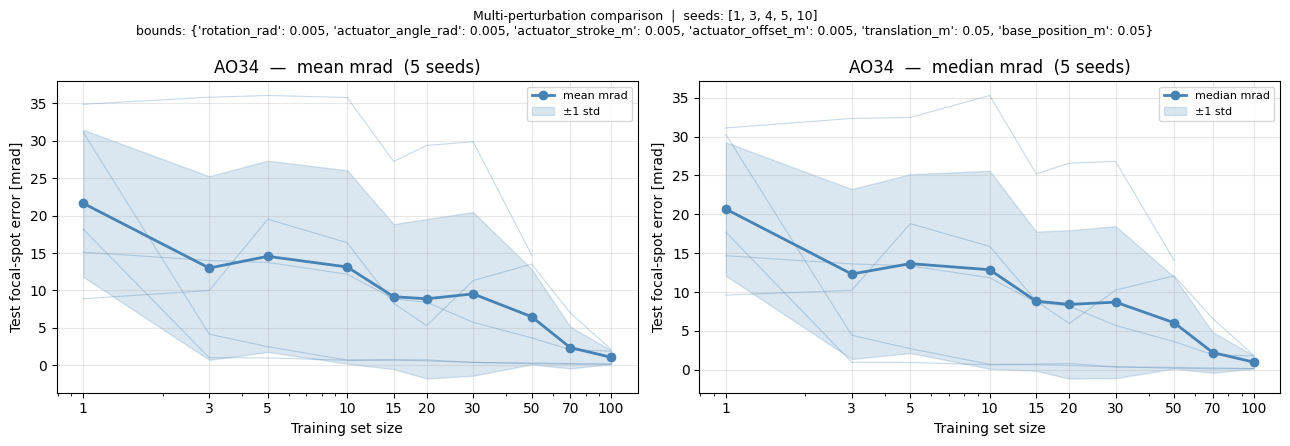


     n    mean_avg    mean_std     med_avg     med_std   n_seeds
--------------------------------------------------------------
     1      21.628       9.808      20.683       8.583         5
     3      12.997      12.250      12.323      10.930         5
     5      14.557      12.765      13.662      11.500         5
    10      13.140      12.900      12.874      12.726         5
    15       9.174       9.680       8.828       8.952         5
    20       8.895      10.646       8.419       9.542         5
    30       9.547      10.921       8.707       9.775         5
    50       6.501       6.361       6.057       5.889         5
    70       2.385       2.788       2.228       2.618         4
   100       1.089       0.917       0.999       0.840         4


In [11]:
_seeds      = list(multi_results.keys())
_all_sizes  = sorted({ts for sr in multi_results.values() for ts in sr})

# Collect per-size arrays — only include seeds that have this train_size
_means_by_size = {ts: [multi_results[s][ts]["mean"] for s in _seeds if ts in multi_results[s]] for ts in _all_sizes}
_meds_by_size  = {ts: [multi_results[s][ts]["med"]  for s in _seeds if ts in multi_results[s]] for ts in _all_sizes}

_sizes_plot = [ts for ts in _all_sizes if _means_by_size[ts]]
_mu_mean  = np.array([np.mean(_means_by_size[ts]) for ts in _sizes_plot])
_std_mean = np.array([np.std( _means_by_size[ts]) for ts in _sizes_plot])
_mu_med   = np.array([np.mean(_meds_by_size[ts])  for ts in _sizes_plot])
_std_med  = np.array([np.std( _meds_by_size[ts])  for ts in _sizes_plot])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, mu, std, label in [
    (axes[0], _mu_mean, _std_mean, "mean"),
    (axes[1], _mu_med,  _std_med,  "median"),
]:
    ax.semilogx(_sizes_plot, mu, "o-", lw=2, color="steelblue", label=f"{label} mrad")
    ax.fill_between(_sizes_plot, mu - std, mu + std, color="steelblue", alpha=0.2, label="±1 std")
    # Individual seed lines (thin, transparent)
    for s in _seeds:
        _xs = [ts for ts in _sizes_plot if ts in multi_results[s]]
        _ys = [multi_results[s][ts]["mean" if label == "mean" else "med"] for ts in _xs]
        ax.semilogx(_xs, _ys, lw=0.8, color="steelblue", alpha=0.3)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Test focal-spot error [mrad]")
    ax.set_title(f"{HELIOSTAT_ID}  —  {label} mrad  ({len(_seeds)} seeds)")
    ax.set_xticks(_sizes_plot); ax.set_xticklabels([str(s) for s in _sizes_plot])
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    f"Multi-perturbation comparison  |  seeds: {_seeds}\n"
    f"bounds: { {k: v for k, v in RANDOM_PERT_BOUNDS.items()} }",
    fontsize=9,
)
plt.tight_layout()
plt.show()

# ---- Numeric table -------------------------------------------------------
print(f"\n{'n':>6}  {'mean_avg':>10}  {'mean_std':>10}  {'med_avg':>10}  {'med_std':>10}  {'n_seeds':>8}")
print("-" * 62)
for ts in _sizes_plot:
    n_s = len(_means_by_size[ts])
    print(
        f"{ts:>6}  "
        f"{np.mean(_means_by_size[ts]):>10.3f}  "
        f"{np.std( _means_by_size[ts]):>10.3f}  "
        f"{np.mean(_meds_by_size[ts]):>10.3f}  "
        f"{np.std( _meds_by_size[ts]):>10.3f}  "
        f"{n_s:>8}"
    )